# Image Restoration AI Pipeline — Interactive Demonstration

This notebook demonstrates the end-to-end automated image restoration system. The pipeline automatically detects degradations (haze, low-light, rain) using a MobileNetV2 CNN classifier, routes the image dynamically, and restores it using Transformer neural networks.

In [1]:
import os
import sys
import cv2
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from PIL import Image
import io

# Ensure project root is in path
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.core.pipeline import RestorationPipeline
from src.core.config import get_config
from src.utils.image import load_image

# Initialize pipeline
config = get_config()
pipeline = RestorationPipeline()
print(f"Pipeline ready! Device: {config.pipeline.device}, Detector: {config.router.detector_type}")

d:\image_drdo\env\Lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


d:\image_drdo\env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\image_drdo\env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: d:\image_drdo\env\Lib\site-packages\lpips\weights\v0.1\vgg.pth


d:\image_drdo\env\Lib\site-packages\lpips\lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(model_path, map_location='cpu'), strict

Pipeline ready! Device: cuda, Detector: learned


## Automated Pipeline Demonstration
Pass any image path to the pipeline — it will auto-detect degradations, route to the required models, and restore the image.

In [2]:
def run_restoration_demo(image_path, reference_path=None):
    if not os.path.exists(image_path):
        print(f"Error: File not found: {image_path}")
        return

    temp_output_path = "temp_restored_demo.png"
    original_np = load_image(image_path)

    # Run restoration pipeline
    result = pipeline.process_image(
        image_path,
        save_path=temp_output_path,
        reference_path=reference_path if (reference_path and os.path.exists(reference_path)) else None
    )

    # Load restored image
    restored_np = load_image(temp_output_path) if os.path.exists(temp_output_path) else original_np

    # Plot results
    num_cols = 3 if (reference_path and os.path.exists(reference_path)) else 2
    fig, axes = plt.subplots(1, num_cols, figsize=(5 * num_cols, 5))

    axes[0].imshow(original_np)
    axes[0].set_title("Degraded Input")
    axes[0].axis("off")

    axes[1].imshow(restored_np)
    axes[1].set_title(f"Restored (Plan: {result['plan']})")
    axes[1].axis("off")

    if num_cols == 3:
        ref_np = load_image(reference_path)
        axes[2].imshow(ref_np)
        axes[2].set_title("Ground-Truth Reference")
        axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    # Print details
    print(f"Latency: {result['latency_ms']:.2f} ms")
    print("Degradation Confidence Scores:")
    for k, v in result["scores"].items():
        print(f"  {k}: {v:.4f}")
    
    print("Quality Metrics:")
    has_fr_metrics = False
    for k, v in result["metrics"].items():
        if v is not None:
            val_str = f"{v:.4f}" if isinstance(v, (int, float)) else str(v)
            if k in ["psnr", "ssim", "lpips"]:
                has_fr_metrics = True
                print(f"  {k.upper()}: {val_str}")
            elif k == "brisque":
                print(f"  BRISQUE (No-Reference Quality): {val_str}")

    if not has_fr_metrics:
        print("  Note: PSNR, SSIM, and LPIPS require a ground-truth reference image.")
        print("  For standalone images, BRISQUE measures perceptual quality (lower score = better quality).")

    # Clean temp output
    if os.path.exists(temp_output_path):
        os.remove(temp_output_path)

### Test Pipeline with Sample Dataset Images

=== Testing Haze Restoration ===
{"timestamp": "2026-08-11T10:31:50.750877", "level": "INFO", "module": "pipeline", "message": "Processing d:\\image_drdo\\images\\haze_test\\hazy\\0001_0.8_0.2.jpg"}
{"timestamp": "2026-08-11T10:31:50.762505", "level": "INFO", "module": "pipeline", "message": "Loading ground-truth reference d:\\image_drdo\\images\\haze_test\\clear\\0001.png"}
{"timestamp": "2026-08-11T10:31:51.132144", "level": "INFO", "module": "learned", "message": "Loaded learned detector weights from D:\\image_drdo\\weights\\detector.pth"}
{"timestamp": "2026-08-11T10:31:52.492227", "level": "INFO", "module": "pipeline", "message": "Degradation scores: {'haze': 0.9964895844459534, 'lowlight': 8.067212547757663e-06, 'rain': 1.4952776837162673e-05}"}
{"timestamp": "2026-08-11T10:31:52.493231", "level": "INFO", "module": "pipeline", "message": "Execution plan: ['haze']"}
{"timestamp": "2026-08-11T10:31:52.526264", "level": "INFO", "module": "pipeline", "message": "Applying model for: h

d:\image_drdo\env\Lib\site-packages\torch\functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:3596.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


{"timestamp": "2026-08-11T10:31:54.847750", "level": "INFO", "module": "pipeline", "message": "Finished processing in 4095.15 ms"}


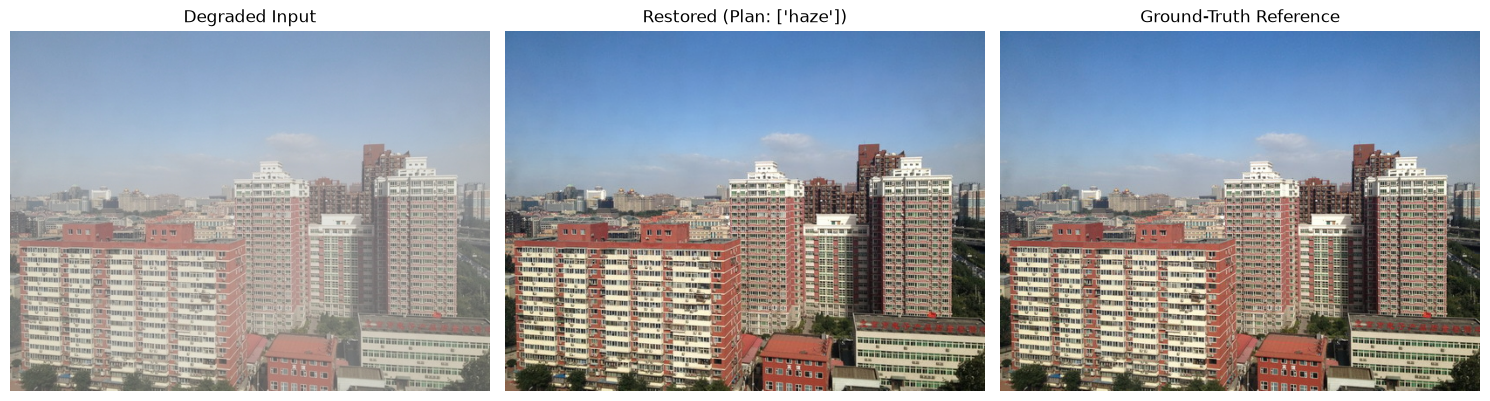

Latency: 4095.15 ms
Degradation Confidence Scores:
  haze: 0.9965
  lowlight: 0.0000
  rain: 0.0000
Quality Metrics:
  PSNR: 38.3625
  SSIM: 0.9921
  LPIPS: 0.0226
  BRISQUE (No-Reference Quality): 24.3068


In [3]:
# Test Haze Image
sample_haze = os.path.join(project_root, "images", "haze_test", "hazy", "0001_0.8_0.2.jpg")
sample_clear = os.path.join(project_root, "images", "haze_test", "clear", "0001.png")
print("=== Testing Haze Restoration ===")
run_restoration_demo(sample_haze, reference_path=sample_clear)

=== Testing Low-Light Restoration ===
{"timestamp": "2026-08-11T10:31:56.476595", "level": "INFO", "module": "pipeline", "message": "Processing d:\\image_drdo\\images\\lowlight_test\\Low\\low00690.png"}
{"timestamp": "2026-08-11T10:31:56.511906", "level": "INFO", "module": "pipeline", "message": "Loading ground-truth reference d:\\image_drdo\\images\\lowlight_test\\Normal\\normal00690.png"}
{"timestamp": "2026-08-11T10:31:56.726700", "level": "INFO", "module": "pipeline", "message": "Degradation scores: {'haze': 0.002017121994867921, 'lowlight': 0.9924232959747314, 'rain': 0.00032149386242963374}"}
{"timestamp": "2026-08-11T10:31:56.736108", "level": "INFO", "module": "pipeline", "message": "Execution plan: ['lowlight']"}
{"timestamp": "2026-08-11T10:31:56.753247", "level": "INFO", "module": "pipeline", "message": "Applying model for: lowlight"}
{"timestamp": "2026-08-11T10:31:56.768152", "level": "INFO", "module": "lowlight_retinexformer", "message": "Loading two-stage low-light pipel

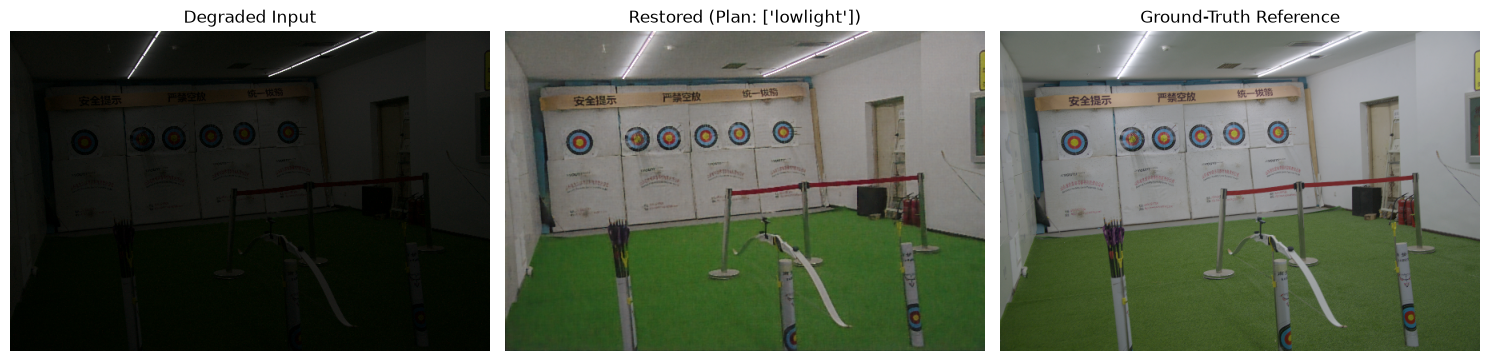

Latency: 3231.94 ms
Degradation Confidence Scores:
  haze: 0.0020
  lowlight: 0.9924
  rain: 0.0003
Quality Metrics:
  PSNR: 24.4450
  SSIM: 0.8618
  LPIPS: 0.2540
  BRISQUE (No-Reference Quality): 6.5861


In [4]:
# Test Low-Light Image
sample_low = os.path.join(project_root, "images", "lowlight_test", "Low", "low00690.png")
sample_normal = os.path.join(project_root, "images", "lowlight_test", "Normal", "normal00690.png")
print("=== Testing Low-Light Restoration ===")
run_restoration_demo(sample_low, reference_path=sample_normal)

=== Testing Rain Removal ===
{"timestamp": "2026-08-11T10:32:00.665589", "level": "INFO", "module": "pipeline", "message": "Processing d:\\image_drdo\\images\\rain_test\\input\\1.png"}
{"timestamp": "2026-08-11T10:32:00.674805", "level": "INFO", "module": "pipeline", "message": "Loading ground-truth reference d:\\image_drdo\\images\\rain_test\\target\\1.png"}
{"timestamp": "2026-08-11T10:32:00.724523", "level": "INFO", "module": "pipeline", "message": "Degradation scores: {'haze': 1.829950520004786e-06, 'lowlight': 1.321161420264616e-07, 'rain': 0.9998155236244202}"}
{"timestamp": "2026-08-11T10:32:00.728413", "level": "INFO", "module": "pipeline", "message": "Execution plan: ['rain']"}
{"timestamp": "2026-08-11T10:32:00.731134", "level": "INFO", "module": "pipeline", "message": "Applying model for: rain"}
{"timestamp": "2026-08-11T10:32:00.732748", "level": "INFO", "module": "derain", "message": "Loading Restormer from D:\\image_drdo\\weights\\deraining.pth"}
{"timestamp": "2026-08-11

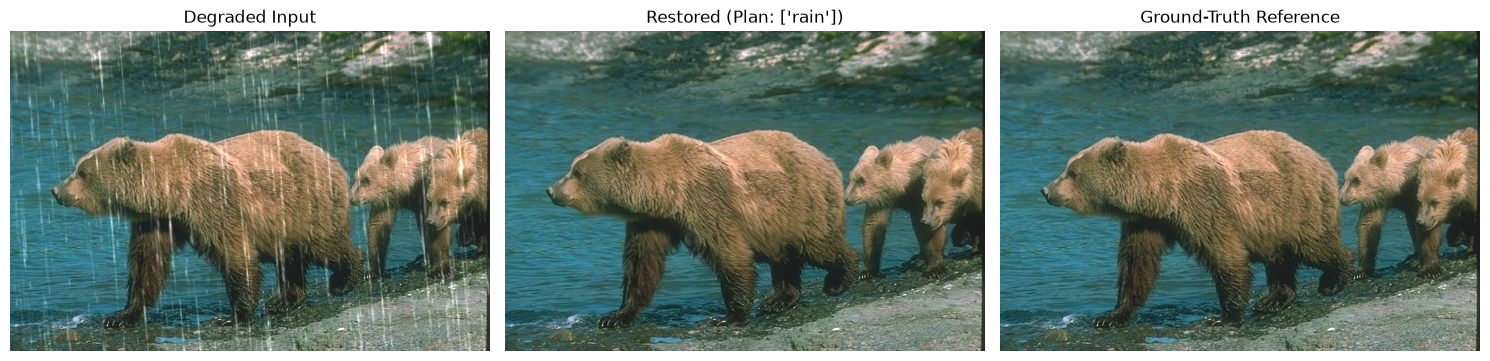

Latency: 2807.51 ms
Degradation Confidence Scores:
  haze: 0.0000
  lowlight: 0.0000
  rain: 0.9998
Quality Metrics:
  PSNR: 37.3037
  SSIM: 0.9758
  LPIPS: 0.0457
  BRISQUE (No-Reference Quality): 22.5256


In [5]:
# Test rain Image
sample_rain = os.path.join(project_root, "images", "rain_test", "input", "1.png")
sample_clear = os.path.join(project_root, "images", "rain_test", "target", "1.png")
print("=== Testing Rain Removal ===")
run_restoration_demo(sample_rain, reference_path=sample_clear)

## Interactive File Uploader
Upload any custom image from your computer, then click **Restore Image** to run the restoration pipeline.

In [ ]:
uploader = widgets.FileUpload(accept='image/*', multiple=False)
restore_btn = widgets.Button(description="Restore Image", button_style='primary', icon='magic')
output_area = widgets.Output()

def on_restore_click(b):
    output_area.clear_output(wait=True)
    with output_area:
        if not uploader.value:
            print("Please select an image file first using the Upload button.")
            return
        
        # Handle ipywidgets 7.x and 8.x formats safely
        try:
            if isinstance(uploader.value, dict):
                fname = list(uploader.value.keys())[0]
                content = uploader.value[fname]['content']
            elif isinstance(uploader.value, (tuple, list)) and len(uploader.value) > 0:
                item = uploader.value[0]
                fname = item.name if hasattr(item, 'name') else item.get('name', 'upload.png')
                content = item.content.tobytes() if hasattr(item.content, 'tobytes') else item.get('content', b'')
            else:
                print("No file content detected.")
                return
        except Exception as e:
            print(f"Upload parsing error: {e}")
            return

        temp_in = f"temp_upload_{fname}"
        temp_out = f"temp_restored_{fname}"
        
        try:
            with open(temp_in, "wb") as f:
                f.write(content)
            
            original_np = load_image(temp_in)
            result = pipeline.process_image(temp_in, save_path=temp_out)
            restored_np = load_image(temp_out) if os.path.exists(temp_out) else original_np
            
            fig, axes = plt.subplots(1, 2, figsize=(10, 5))
            axes[0].imshow(original_np)
            axes[0].set_title("Uploaded Original")
            axes[0].axis("off")
            
            axes[1].imshow(restored_np)
            axes[1].set_title(f"Restored (Plan: {result['plan']})")
            axes[1].axis("off")
            
            plt.tight_layout()
            plt.show()
            
            print(f"Latency: {result['latency_ms']:.2f} ms")
            print("Degradation Confidence Scores:")
            for k, v in result["scores"].items():
                print(f"  {k}: {v:.4f}")
                
            print("Quality Metrics:")
            has_fr_metrics = False
            for k, v in result["metrics"].items():
                if v is not None:
                    val_str = f"{v:.4f}" if isinstance(v, (int, float)) else str(v)
                    if k in ["psnr", "ssim", "lpips"]:
                        has_fr_metrics = True
                        print(f"  {k.upper()}: {val_str}")
                    elif k == "brisque":
                        print(f"  BRISQUE (No-Reference Quality): {val_str}")

            if not has_fr_metrics:
                print("  Note: PSNR, SSIM, and LPIPS require a ground-truth reference image.")
                print("  For standalone uploads, BRISQUE measures perceptual quality (lower score = better quality).")
                
        finally:
            for p in [temp_in, temp_out]:
                if os.path.exists(p):
                    os.remove(p)

restore_btn.on_click(on_restore_click)
display(widgets.VBox([
    widgets.HTML("<h3>Interactive File Restoration:</h3>"),
    widgets.HBox([uploader, restore_btn]),
    output_area
]))